In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import norm
from pathlib import Path

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA = PROJECT_ROOT / "data"

HISTORICAL = DATA / "historical"
OPTIONS = DATA / "options"
REPORT = PROJECT_ROOT / "report"

In [4]:
spy = pd.read_csv(
    HISTORICAL / "SPY_1Y.csv",
    skiprows=[1]
)

numeric_cols = [
    "Close",
    "High",
    "Low",
    "Open",
    "Volume"
]

spy[numeric_cols] = spy[numeric_cols].apply(pd.to_numeric)

spy.head()

,Close,High,Low,Open,Volume
0,625.845459,626.498200,621.246394,622.156295,64357500
1,625.321228,629.999373,622.215625,629.267492,74205800
2,630.197205,630.662085,626.794901,627.111401,64051600
3,628.951050,631.947874,627.704848,630.474212,58742300
4,635.646851,635.805071,629.811484,631.295045,64730800


In [5]:
calls = pd.read_csv(
    OPTIONS / "SPY_Calls.csv"
)

calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260806C00630000,2026-08-05 18:08:22+00:00,630.0,141.86,0.0,0.0,0.0,0.0,1.0,1,0.00001,True,REGULAR,USD
1,SPY260806C00675000,2026-07-30 14:47:04+00:00,675.0,63.40,0.0,0.0,0.0,0.0,NaN,0,0.00001,True,REGULAR,USD
2,SPY260806C00680000,2026-08-05 19:59:32+00:00,680.0,90.70,0.0,0.0,0.0,0.0,10.0,8,0.00001,True,REGULAR,USD
3,SPY260806C00685000,2026-07-27 15:32:15+00:00,685.0,54.90,0.0,0.0,0.0,0.0,1.0,1,0.00001,True,REGULAR,USD
4,SPY260806C00700000,2026-08-03 14:23:19+00:00,700.0,54.45,0.0,0.0,0.0,0.0,2.0,1,0.00001,True,REGULAR,USD


In [6]:
spy_price = spy["Close"].iloc[-1]

print(f"Current SPY Price = {spy_price:.2f}")

Current SPY Price = 769.79


In [7]:
calls["Distance"] = abs(
    calls["strike"] - spy_price
)

atm = calls.loc[
    calls["Distance"].idxmin()
]

atm

contractSymbol              SPY260806C00770000
lastTradeDate        2026-08-05 20:14:59+00:00
strike                                   770.0
lastPrice                                 2.74
bid                                        0.0
ask                                        0.0
change                                     0.0
percentChange                              0.0
volume                                 19182.0
openInterest                              6232
impliedVolatility                     0.001963
inTheMoney                               False
contractSize                           REGULAR
currency                                   USD
Distance                              0.210022
Name: 63, dtype: object

In [8]:
S = spy_price

K = atm["strike"]

sigma = atm["impliedVolatility"]

T = 7 / 365

r = 0.04

In [9]:
d1 = (
    np.log(S / K)
    +
    (r + sigma**2 / 2) * T
) / (
    sigma * np.sqrt(T)
)

delta = norm.cdf(d1)

print(f"Call Delta = {delta:.4f}")

Call Delta = 0.9655


In [10]:
contracts = 10

portfolio_delta = delta * contracts * 100

print(f"Portfolio Delta = {portfolio_delta:.2f}")

Portfolio Delta = 965.50


In [11]:
hedge_shares = portfolio_delta

print(f"Shares to Short = {hedge_shares:.0f}")

Shares to Short = 966


In [12]:
new_delta = 0.60

new_portfolio_delta = (
    new_delta
    * contracts
    * 100
)

new_hedge = new_portfolio_delta

print(f"Old Hedge = {hedge_shares:.0f} shares")

print(f"New Hedge = {new_hedge:.0f} shares")

Old Hedge = 966 shares
New Hedge = 600 shares


In [13]:
adjustment = (
    new_hedge
    -
    hedge_shares
)

print(f"Additional Shares to Short = {adjustment:.0f}")

Additional Shares to Short = -366


In [14]:
summary = pd.DataFrame({

    "Metric":[

        "Current SPY Price",
        "Option Delta",
        "Contracts",
        "Portfolio Delta",
        "Initial Hedge Shares",
        "New Delta",
        "New Hedge Shares",
        "Adjustment Required"

    ],

    "Value":[

        round(spy_price,2),
        round(delta,4),
        contracts,
        round(portfolio_delta,2),
        round(hedge_shares,0),
        new_delta,
        round(new_hedge,0),
        round(adjustment,0)

    ]

})

summary

,Metric,Value
0,Current SPY Price,769.7900
1,Option Delta,0.9655
2,Contracts,10.0000
3,Portfolio Delta,965.5000
4,Initial Hedge Shares,966.0000
5,New Delta,0.6000
6,New Hedge Shares,600.0000
7,Adjustment Required,-366.0000


In [15]:
summary.to_csv(

    REPORT /
    "Day44_Delta_Hedging.csv",

    index=False

)

print("Summary Saved")

Summary Saved


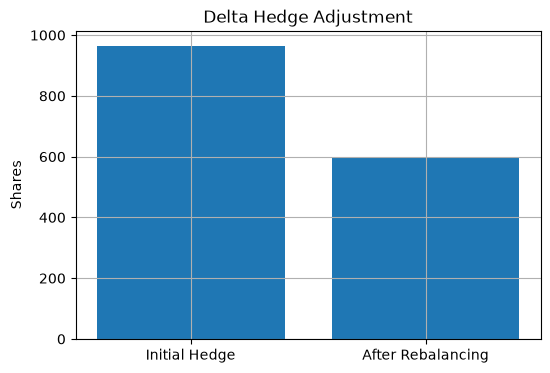

In [16]:
plt.figure(figsize=(6,4))

plt.bar(

    ["Initial Hedge",
     "After Rebalancing"],

    [hedge_shares,
     new_hedge]

)

plt.ylabel("Shares")

plt.title("Delta Hedge Adjustment")

plt.grid()

plt.savefig(

    REPORT /
    "Delta_Hedge.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [17]:
print("----------- DAY 44 DELTA HEDGING -----------\n")

print(f"Current SPY Price       : {spy_price:.2f}")

print(f"Option Delta           : {delta:.4f}")

print(f"Contracts              : {contracts}")

print()

print(f"Portfolio Delta        : {portfolio_delta:.2f}")

print(f"Initial Hedge Shares   : {hedge_shares:.0f}")

print()

print(f"New Delta              : {new_delta:.2f}")

print(f"New Hedge Shares       : {new_hedge:.0f}")

print(f"Adjustment Required    : {adjustment:.0f}")

print()

if adjustment > 0:
    print(f"Short an additional {adjustment:.0f} SPY shares.")
elif adjustment < 0:
    print(f"Buy back {-adjustment:.0f} SPY shares.")
else:
    print("No hedge adjustment required.")

print("\nAnalysis Complete.")

----------- DAY 44 DELTA HEDGING -----------

Current SPY Price       : 769.79
Option Delta           : 0.9655
Contracts              : 10

Portfolio Delta        : 965.50
Initial Hedge Shares   : 966

New Delta              : 0.60
New Hedge Shares       : 600
Adjustment Required    : -366

Buy back 366 SPY shares.

Analysis Complete.
